# PeoplePulse AI — Exploratory Data Analysis
### Quick-start notebook for exploring the HR dataset, KPIs, and ML risk scores

This notebook complements (does not replace) the production scripts:
- `data/generate_hr_dataset.py` — dataset generation
- `ml_models/train_attrition_model.py` — full ML pipeline
- `sql/validation/run_validation.sql` — database-level validation

Use this notebook for ad-hoc exploration, charting experiments, and
sanity-checking before committing changes to the production scripts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 30)
plt.style.use('default')
sns.set_palette("Blues_r")

df = pd.read_csv('../data/PeoplePulse_HR_Dataset.csv')
df['Exit_Reason'] = df['Exit_Reason'].fillna('N/A')
print(f"Shape: {df.shape}")
df.head()

Shape: (10000, 24)


,Employee_ID,Employee_Name,Age,Gender,Department,Job_Role,Job_Level,Manager_ID,Location,Work_Mode,Years_At_Company,Salary,Bonus,Recruitment_Source,Performance_Rating,Performance_Label,Attendance_Pct,Training_Hours,Engagement_Score,Satisfaction_Score,Promotions,Leave_Count,Attrition,Exit_Reason
0,EMP10001,Mark Johnson,45,Male,Sales,Senior Account Executive,L4,EMP11762,"New York, NY",Hybrid,4.30,179000,31000,LinkedIn,4,Exceeds Expectations,84.4,74.3,72.1,64.5,3,11,No,N/A
1,EMP10002,Denise Walker,29,Female,Engineering,Principal Engineer,L5,EMP10409,"London, UK",Hybrid,4.60,242000,44500,LinkedIn,3,Meets Expectations,88.0,54.6,72.8,76.1,1,8,No,N/A
2,EMP10003,Nancy Rhodes,41,Female,Marketing,Senior Marketing Manager,L4,EMP17395,"Seattle, WA",On-site,0.25,154000,23500,LinkedIn,3,Meets Expectations,94.8,35.9,70.2,62.6,0,16,Yes,Better Opportunity
3,EMP10004,Stephanie Miller,54,Female,Sales,Sales Development Rep,L2,EMP18277,"Austin, TX",On-site,5.60,93000,50000,Recruiter/Agency,3,Meets Expectations,92.0,36.4,60.3,50.4,0,10,Yes,Role Mismatch
4,EMP10005,Javier Johnson,33,Male,Sales,Sales Development Rep,L2,EMP15779,"New York, NY",On-site,2.60,108000,20000,Employee Referral,3,Meets Expectations,91.3,38.4,54.5,54.0,2,11,No,N/A


## 1. Headline KPIs

In [2]:
attrition_rate = (df['Attrition'] == 'Yes').mean()
avg_salary = df['Salary'].mean()
avg_engagement = df['Engagement_Score'].mean()
avg_tenure = df['Years_At_Company'].mean()

print(f"Attrition Rate:    {attrition_rate:.1%}")
print(f"Avg Salary:        ${avg_salary:,.0f}")
print(f"Avg Engagement:    {avg_engagement:.1f}/100")
print(f"Avg Tenure:        {avg_tenure:.1f} years")

Attrition Rate:    23.8%
Avg Salary:        $169,954
Avg Engagement:    67.3/100
Avg Tenure:        3.6 years


## 2. Attrition by Department

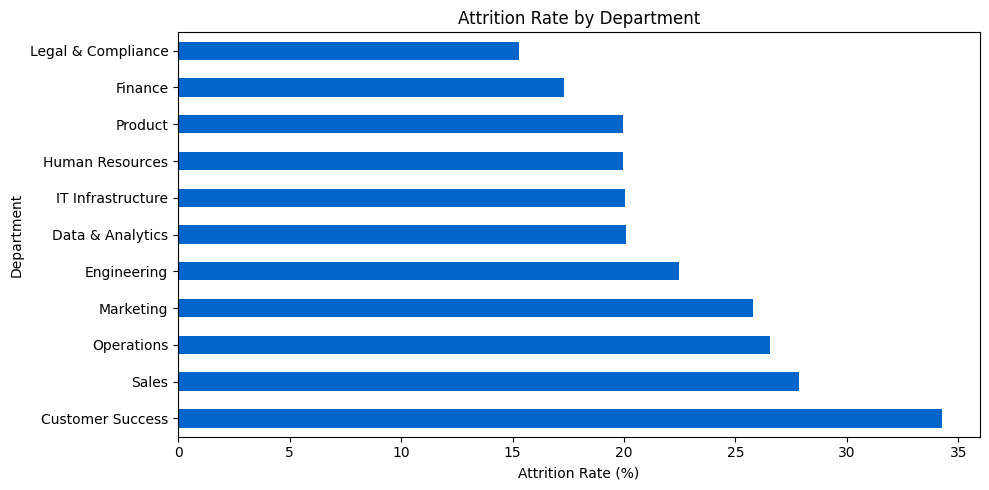

Department
Customer Success      34.252540
Sales                 27.828571
Operations            26.530612
Marketing             25.806452
Engineering           22.458202
Data & Analytics      20.077220
IT Infrastructure     20.040486
Human Resources       19.961612
Product               19.951338
Finance               17.289073
Legal & Compliance    15.277778
Name: Attrition, dtype: float64

In [3]:
dept_attrition = df.groupby('Department')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,5))
dept_attrition.plot(kind='barh', ax=ax, color='#0066CC')
ax.set_xlabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Department')
plt.tight_layout()
plt.show()

dept_attrition

## 3. Engagement vs Attrition

/tmp/ipykernel_608/4198252153.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='Engagement_Score', ax=ax, palette=['#1D9E75','#D85A30'])


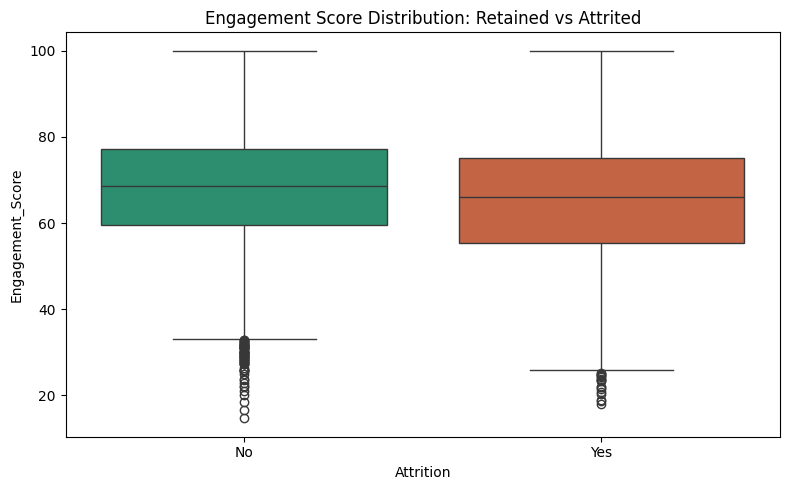

In [4]:
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df, x='Attrition', y='Engagement_Score', ax=ax, palette=['#1D9E75','#D85A30'])
ax.set_title('Engagement Score Distribution: Retained vs Attrited')
plt.tight_layout()
plt.show()

## 4. Load ML Risk Predictions (if available)

In [5]:
import os
pred_path = '../ml_models/attrition_predictions.csv'
if os.path.exists(pred_path):
    preds = pd.read_csv(pred_path)
    tier_order = ['Low','Medium','High','Critical']
    validation = preds.groupby('Risk_Tier')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).reindex(tier_order)
    print("Actual attrition rate by predicted risk tier:")
    print(validation)
else:
    print("Run ml_models/train_attrition_model.py first to generate predictions.")

Actual attrition rate by predicted risk tier:
Risk_Tier
Low         16.060806
Medium      25.273186
High        35.369993
Critical    54.415274
Name: Attrition, dtype: float64


## 5. Compensation Equity Quick Check

In [6]:
level_medians = df.groupby('Job_Level')['Salary'].median()
df['Compa_Ratio'] = df['Salary'] / df['Job_Level'].map(level_medians)

gap = df.groupby(['Job_Level','Gender'])['Salary'].mean().unstack()
gap['Gap_%'] = (gap['Male'] - gap['Female']) / gap['Male'] * 100
gap[['Male','Female','Gap_%']].round(1)

Gender,Male,Female,Gap_%
Job_Level,,,
L2,92647.4,92661.4,-0.0
L3,125928.4,124699.7,1.0
L4,167206.3,160931.5,3.8
L5,230882.9,222728.8,3.5
L6,263006.0,259091.5,1.5
L7,358453.5,360258.9,-0.5
L8,480733.3,480900.0,-0.0
